In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import get_expected_cis_df, prepare_view_df, CLR_CONNS
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution=resolution)

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import importlib
from ggner_3d import plotting
importlib.reload(plotting)
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [3]:
# data paths

# XPC

xpc_wt_dict = {
'wt_nouv_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
]
}

### TADs prep

In [5]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/insulation/insulation_{k}_10000bp.csv') for k in ['WTnoUV', 'XPCnoUV']]

comparisons = [(0,1)]
comparisons_str = ['WTnoUV_XPCnoUV']
sample_names_str = ['WTnoUV', 'XPCnoUV']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

WTnoUV_XPCnoUV: Preserved / Increase ::: 2378
WTnoUV_XPCnoUV: Preserved / Decrease ::: 358


In [6]:
expected_ = {
    'WTnoUV': get_expected_cis_df('WTnoUV', resolution_kb=resolution//1000, label='chrom'),
    'XPCnoUV': get_expected_cis_df('XPCnoUV', resolution_kb=resolution//1000, label='chrom'),
}

wtnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['WTnoUV'],
                    expected=expected_['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

xpcnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['XPCnoUV'],
                    expected=expected_['XPCnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

tads_ds_merged = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    xpcnouv_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_XPCnoUV')
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 130
INFO:coolpuppy:('chr6', 'chr6'): 148
INFO:coolpuppy:('chr4', 'chr4'): 159
INFO:coolpuppy:('chr8', 'chr8'): 125
INFO:coolpuppy:('chr5', 'chr5'): 152
INFO:coolpuppy:('chr3', 'chr3'): 169
INFO:coolpuppy:('chr1', 'chr1'): 211
INFO:coolpuppy:('chr2', 'chr2'): 192
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr13', 'chr13'): 75
INFO:coolpuppy:('chr14', 'chr14'): 75
INFO:coolpuppy:('chr10', 'chr10'): 111
INFO:coolpuppy:('chr11', 'chr11'): 142
INFO:coolpuppy:('chr17', 'chr17'): 66
INFO:coolpuppy:('chr16', 'chr16'): 64
INFO:coolpuppy:('chr12', 'chr12'): 123
INFO:coolpuppy:('chr21', 'chr21'): 19
INFO:coolpuppy:('chr19', 'chr19'): 56
INFO:coolpuppy:('chr15', 'chr15'): 79
INFO:coolpuppy:('chr18', 'chr18'): 61
INFO:coolpuppy:('chr22', 'chr22'): 28
INFO:coolpuppy:('chr20', 'chr20'): 65
INFO:coolpuppy:('chrX', 'chrX'): 91
INFO:coolpuppy:Total number of piled up windows: 211
INFO:coolpuppy:Res

In [ ]:
# tads = tads_ds_merged.copy()

# tads['ds_Q'] = pd.qcut(tads['domain_score_Degron'], q=4, labels=False) + 1

# tads = tads.dropna(subset=['ds_Q']).reset_index(drop=True)
# print(tads['ds_Q'].value_counts())

# flank_ratio = 0.25
# tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
# tads['flank_start'] = tads['start'] - tads['flank_size']
# tads['flank_end'] = tads['end'] + tads['flank_size']

In [ ]:
from ggner_3d.bbi_helpers import stackup_bw_dict_q, stackup_bw_dict

In [9]:
tads_fmt = tads.copy()
tads_fmt['flank_start'] = tads_fmt['start']
tads_fmt['flank_end'] = tads_fmt['end']

stack = stackup_bw_dict(
    xpc_wt_dict,
    tads_fmt,
    nbins=1
)

stack = stack['wt_nouv_xpc'].flatten()
tads_fmt['xpc_signal'] = stack
tads_fmt['ds_Q'] = pd.qcut(tads_fmt['xpc_signal'], q=4, labels=False) + 1

In [10]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)

nbins = 600

In [11]:
mean_per_q = False

In [12]:
# q stackups - TADS

flank_ratio = 1 
tads_fmt['length'] = tads_fmt['end'] - tads_fmt['start']
tads_fmt['flank_size'] = tads_fmt['length'] * flank_ratio
tads_fmt['flank_start'] = tads_fmt['start'] - tads_fmt['flank_size']
tads_fmt['flank_end'] = tads_fmt['end'] + tads_fmt['flank_size']

control_xpc = stackup_bw_dict_q(xpc_wt_dict['wt_nouv_xpc'], tads_fmt, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:34: RuntimeWarning: Mean of empty slice
  _rep_avg = np.nanmean(np.array(_rep_avg), axis=0)


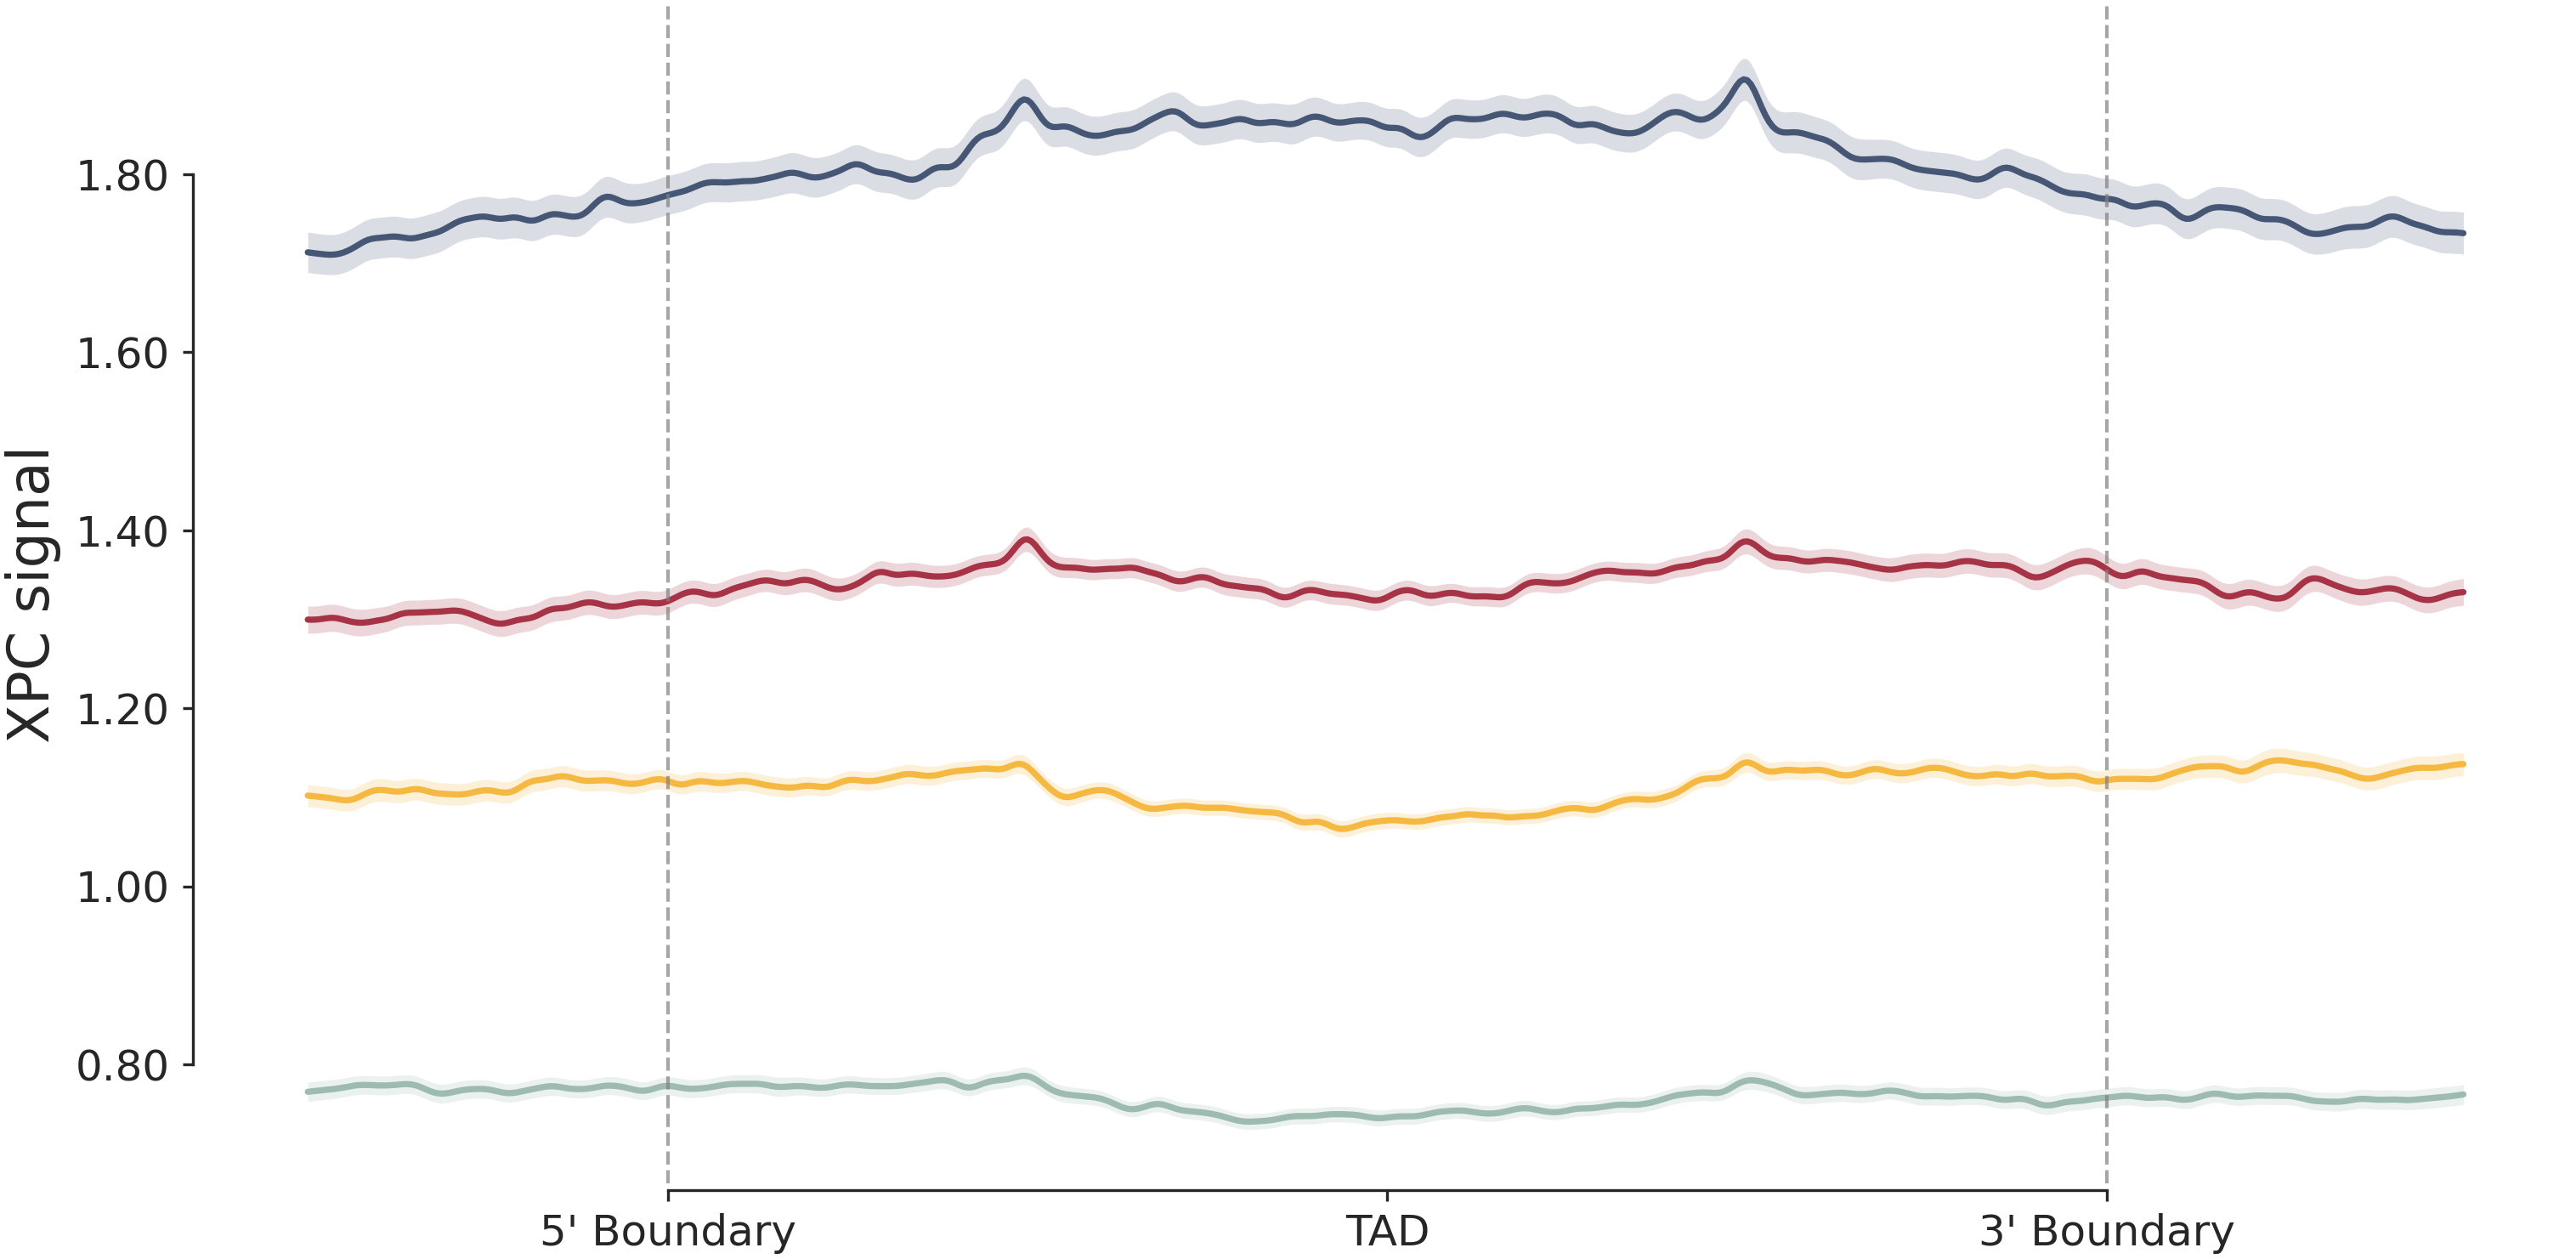

In [13]:
colors = list(reversed(plotting.COLORS))
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS)),
    'smooth_sigma': 3.0,
}

lineplot_stackup_dict(
    control_xpc,
    ax=ax,
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='XPC signal quartiles',
    y_title='XPC signal',
    structure_type='TAD',
    **common_params
)

# --- Axis cosmetics ---
plotting.despine(ax=ax)
ax.set_xlabel("")
# make x, y labels bigger
ax.set_ylabel(ax.get_ylabel(), fontsize=16)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
# remove legends
legend = ax.get_legend()
if legend is not None:
    legend.remove()
# make x and y ticks bigger
ax.tick_params(axis='both', which='major', labelsize=12)

# make y ticks 2 digits after comma
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

### Hi-C pileups

In [ ]:

pileups = {
    i: [] for i in range(1, 5)
}
from coolpuppy import coolpup

view_df = prepare_view_df(arm=False)

for i in range(1, 5):
    tads_q = tads[tads.ds_Q == i][['chrom', 'start', 'end']].reset_index(drop=True)

    cc = coolpup.CoordCreator(tads_q, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_degron = coolpup.PileUpper(clr_['Degron'], cc, expected=expected_['Degron'], view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pup_control = coolpup.PileUpper(clr_['Control'], cc, expected=expected_['Control'], view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pileups[i] = (pup_control, pup_degron)

AttributeError: 'DataFrame' object has no attribute 'ds_Q'

In [ ]:
from ggner_3d.plotting import lineplot_stackup_array

In [ ]:
# two-row pileup panel
# row 1 = log2 pileups[i][0]
# row 2 = log2 fold-change = log2(pileups[i][1] / pileups[i][0])
# row 3 = chipseq

eps = 1e-6

# precompute matrices
all_base = []
all_diffs = []
for i in range(1, 5):
    base_mtx = np.log2(pileups[i][0]['data'][0] + eps)
    diff_mtx = np.log2((pileups[i][1]['data'][0] + eps) / (pileups[i][0]['data'][0] + eps))
    
    all_base.append(base_mtx)
    all_diffs.append(diff_mtx)

# color scales
base_vmin, base_vmax = -1.5, 1.5
diff_vmin, diff_vmax = -0.2, 0.2

aspect_ratio = 4.8
fig, axs = plt.subplots(3, 4, figsize=(4 * aspect_ratio, 2 * aspect_ratio), sharey='row')
plotting.update_rcparams()

for i in range(1, 5):
    # -------------------------
    # first row: base heatmaps
    # -------------------------
    base_mtx_comp = all_base[i - 1]

    ax = plotting.hic_upper_triangle(
        base_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=base_vmin,
        vmax=base_vmax,
        ax=axs[0, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = base_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

    plotting.despine(ax)

    # -------------------------
    # second row: L2FC heatmaps
    # -------------------------
    diff_mtx_comp = all_diffs[i - 1]

    ax = plotting.hic_upper_triangle(
        diff_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=diff_vmin,
        vmax=diff_vmax,
        ax=axs[1, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = diff_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC", labelpad=5)

    plotting.despine(ax)

    current_line_data = control_pol2[i]

    ax = axs[2, i - 1]

    common_params = {
        "plot_kwargs": {"linewidth": 1.75},
        "color": plotting.COLORS[0],
        "smooth_sigma": 3.0,
        "flank_ratio": 1
    }

    lineplot_stackup_array(
        current_line_data,
        ax=ax,
        label=f"Q{i}",
        legend_title="Pol2 signal quartiles",
        y_title="preDegron\nPol2 signal",
        structure_type="TAD",
        **common_params,
    )
    

# rasterize heatmaps only
for ax in axs.ravel():
    for artist in ax.get_images():
        artist.set_rasterized(True)

    for artist in ax.collections:
        artist.set_rasterized(True)